## Defining CLASS and loading files!

In [9]:
from mpi4py import MPI
import numpy as np
import sys
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/')
from functions import parse_parameters
from functions import load_data
from functions import print_error
from functions import print_usage
from functions import create_empty_dataframe
from functions import save_dataframe
from multiprocessing import Lock
import pickle
import numpy as np
import pandas as pd
import os
from library_snapshot import sim_analysis as analysis
import time
import psutil

############
# MPI
############
lock = Lock()
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
n_cores = comm.Get_size()

############
# Parsing the settings
############
start_time_all = time.time()
start_mem_all = psutil.Process().memory_info().rss
sim_size_ini, boxsize, bulk_species_ini, snap_num_ini, sim_type_ini, \
save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, file = parse_parameters()
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
obj = analysis.sim(boxsize);
# pos, vel = load_data(sim_size_ini[0], sim_type_ini[0], bulk_species_ini[0], snap_num_ini[0], sim_path, file, obj, verbose=False);
# if sim_type_ini[0]=="0.0ev":
#     if bulk_species_ini[0] == "nu":
#         print_error("In the case of LCDM we don't have nu snapshots!")
        
# if rank==0:
#     print_usage(start_time_all, start_mem_all, ', Data initialized!')
#     print("Number of cores being used:", n_cores)

In [10]:
 parse_parameters()

(['L_2048_Ngrid_4096'],
 2048.0,
 ['halo'],
 [4],
 ['0.3ev'],
 './output/',
 '/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/simulations_JulianAdamek',
 10,
 11,
 1,
 '/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/simulations_JulianAdamek/nu300meV_2048box_4096_snap004_halos.dat')

In [124]:
df[df['sub_box_index'].apply(lambda x: x == [0, 0, 0])].iloc[0]['halo_vel']

array([[ 27391.44,  52640.9 ,  17127.58],
       [ 28535.35,  51462.46,  17600.74],
       [ 28687.51,  52976.07,  17235.18],
       [  9703.83,  59212.64,  12192.46],
       [  8855.81,  59789.44,  11746.93],
       [  8881.55,  60220.34,  11716.96],
       [  8740.56,  61227.75,   9699.3 ],
       [  8445.05,  61689.89,   9715.68],
       [  8804.96,  60712.58,  11332.48],
       [  9367.41,  60298.6 ,  10888.49],
       [  8617.41,  61369.75,  10273.34],
       [  8617.09,  61302.47,  10753.67],
       [ 92544.79,  70698.23,  20732.72],
       [ 95631.53,  72145.16,  19144.95],
       [ 94386.78,  69681.77,  23709.09],
       [ 94530.7 ,  69339.99,  24751.41],
       [ 26898.3 ,  18820.55,  16547.69],
       [ 30109.35,  17978.95,  17982.96],
       [ 32444.65,  18806.48,  18753.95],
       [  9248.63,   7868.16,  17486.34],
       [ 10140.04,   8384.74,  16638.88],
       [ 86233.19,   7442.75,  44702.68],
       [ 66788.8 ,  38267.14,  74294.97],
       [ 65961.7 ,  38703.25,  769

In [110]:
df['halo_mass'][2]==df_p['halo_mass'][2]

array([ True,  True,  True, ...,  True,  True,  True])

In [102]:
comparison = (df['sub_box_index'] == df_p['sub_box_index']).all()
# comparison = (df['halo_vel'] == df_p['halo_vel']).all()
# comparison = (df['halo_mass'][0] == df_p['halo_mass'][0]).all()
# comparison = (df['bulk_vel'][0] == df_p['bulk_vel'][0]).all()


if comparison:
    print("All elements are equal")
else:
    print("Some elements are different")

All elements are equal


In [51]:
df['halo_mass'] 

0     [236180000000000.0, 1428200000000000.0, 445450...
1     [28179000000000.0, 58897000000000.0, 174150000...
2     [122960000000000.0, 1441900000000000.0, 857060...
3     [54243000000000.0, 70406000000000.0, 108150000...
4     [119990000000000.0, 83099000000000.0, 29872000...
                            ...                        
59    [59743000000000.0, 58559000000000.0, 197850000...
60    [172710000000000.0, 75314000000000.0, 78699000...
61    [250990000000000.0, 415240000000000.0, 1777100...
62    [68375000000000.0, 659120000000000.0, 13125000...
63    [95116000000000.0, 196150000000000.0, 25818000...
Name: halo_mass, Length: 64, dtype: object

In [68]:
df

,halo_vel,halo_mass,bulk_vel,halo_pos,sub_box_index
0,"[[455089.94, 449746.09, 422823.41], [454805.62...","[236180000000000.0, 1428200000000000.0, 445450...","[253765.76129440838, 252200.67237514158, 25498...","[[449.69705, 422.85663, 455.09814], [449.05725...","[0, 0, 0]"
1,"[[555267.75, 407793.78, 507771.41], [559023.5,...","[28179000000000.0, 58897000000000.0, 174150000...","[772658.5205572542, 262775.13391557353, 259368...","[[407.81857, 507.77173, 555.27515], [406.06705...","[0, 0, 1]"
2,"[[1024830.06, 197232.3, 20716.76], [1024407.06...","[122960000000000.0, 1441900000000000.0, 857060...","[1284380.4981118299, 256869.8710869352, 254944...","[[197.2229, 20.71978, 1024.84167], [196.34383,...","[0, 0, 2]"
3,"[[1995843.62, 61326.45, 482887.38], [1999123.2...","[54243000000000.0, 70406000000000.0, 108150000...","[1797766.9173089569, 251149.9347650837, 256911...","[[61.26617, 482.89587, 1995.84204], [60.85214,...","[0, 0, 3]"
4,"[[225311.38, 170807.05, 962812.75], [225063.38...","[119990000000000.0, 83099000000000.0, 29872000...","[248710.39684393007, 256533.65085555497, 77348...","[[170.84886, 962.83606, 225.31683], [169.98207...","[0, 1, 0]"
...,...,...,...,...,...
59,"[[1984857.75, 1779272.5, 1432257.25], [1985940...","[59743000000000.0, 58559000000000.0, 197850000...","[1790486.0273617993, 1793112.4868283137, 12806...","[[1779.21667, 1432.21582, 1984.84729], [1778.2...","[3, 2, 3]"
60,"[[116982.62, 1605749.12, 1651770.88], [112322....","[172710000000000.0, 75314000000000.0, 78699000...","[252483.63470876188, 1789763.4385240308, 17949...","[[1605.70093, 1651.78955, 116.97972], [1605.56...","[3, 3, 0]"
61,"[[999337.19, 1930881.5, 1856286.62], [999788.9...","[250990000000000.0, 415240000000000.0, 1777100...","[766477.2181845543, 1792093.906245154, 1788977...","[[1930.92102, 1856.28711, 999.31415], [1931.60...","[3, 3, 1]"
62,"[[1024927.56, 1769237.5, 1732058.5], [1025282....","[68375000000000.0, 659120000000000.0, 13125000...","[1277669.6773482894, 1788501.0333022014, 17816...","[[1769.17151, 1732.04858, 1024.95471], [1769.1...","[3, 3, 2]"


In [45]:
import pandas as pd

diff = a.compare(b)
print(diff)

AttributeError: 'numpy.ndarray' object has no attribute 'compare'

In [39]:
a == b

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       ...,
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

In [26]:
# main part:
start_time = time.time()
start_mem = psutil.Process().memory_info().rss

for ngrid in [4]: 
    sub_box_lists = obj.All_sub_box(ngrid);
    df = create_empty_dataframe(['halo_vel', 'halo_mass', 'bulk_vel' ,'halo_pos', 'sub_box_index']);
    
    for i in range(np.shape(sub_box_lists)[0]):
        sub_box_index = sub_box_lists[i]
        halos_i = obj.halos_in_cell(ngrid, pos, vel, mass, sub_box_index) # Gives the information of halos in a cell defined by sub-box index!
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos, vel, sub_box_index)[:3] # Bulk velocities using halos
        data_saved = {
            'halo_vel':halos_i[:,3:6],
            'halo_mass':halos_i[:,6],
            'bulk_vel':bulk_vel_halos_i[0],
            'halo_pos': halos_i[:,0:3],
            'sub_box_index': sub_box_index
              }
        df = df.append(data_saved, ignore_index=True)
        # print_usage(start_time, start_mem, 'sub_box='+str(i))

    save_dataframe(df, sim_size_ini, boxsize, ngrid, bulk_species_ini, snap_num_ini, sim_type_ini, save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file, n_cores)
    print_usage(start_time, start_mem, ', n_grid= '+str(ngrid)+' Finished!')


Walltime: 7.53 seconds, Memory usage: 4.97 MB, n_grid= 4 Finished!


In [10]:
# sub_box_lists = obj.All_sub_box(ngrid);
def All_sub_box(ngrid):
    """
    Given the number of grids this function generates and returns all sub-box indices.

    Parameters:
        ngrid (int): number of grids in the simulation
        
    Returns:
        A tuple of length ngrid^3 containing all sub-box indices.
    """
    indices=[]
    for i in range(ngrid):
        for j in range(ngrid):
            for k in range(ngrid):
                indices.append((i, j, k))    
    return tuple(indices)



In [11]:
All_sub_box(3)

((0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 2, 0),
 (0, 2, 1),
 (0, 2, 2),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 2, 0),
 (1, 2, 1),
 (1, 2, 2),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 2, 0),
 (2, 2, 1),
 (2, 2, 2))

In [12]:
for sub_box_index in sub_box_lists:
    i, j, k = sub_box_index
    print(i)

0
0
0
0
1
1
1
1


In [17]:
with open('./output/data_ngrid_2_sim_L_2048_Ngrid_4096_0.3ev_snap_4.pickle','rb') as handle:
    df = pickle.load(handle)


In [1]:
from mpi4py import MPI
import numpy as np
from functions import parse_parameters
from functions import load_data
from functions import print_usage
from functions import create_empty_dataframe
from functions import save_dataframe
from multiprocessing import Lock
import pickle
import numpy as np
import pandas as pd
import os
from library_snapshot import sim_analysis as analysis
import time
import psutil

############
# MPI
############
lock = Lock()
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
n_cores = comm.Get_size()

############
# Parsing the settings
############
start_time = time.time()
start_mem = psutil.Process().memory_info().rss
sim_size_ini, boxsize, bulk_species_ini, snap_num_ini, sim_type_ini, \
save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file = parse_parameters()
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
obj = analysis.sim(boxsize);
pos, vel, mass = load_data(sim_size_ini[0], sim_type_ini[0], bulk_species_ini[0], snap_num_ini[0], sim_path, halo_file, obj, verbose=False);
if rank==0:
    print_usage(start_time, start_mem, ', Data initialized!')
    print("Number of cores being used:", n_cores)
    

############
# main part:
############
start_time = time.time()
start_mem = psutil.Process().memory_info().rss
from mpi4py import MPI
import numpy as np

# main part:
start_time = time.time()
start_mem = psutil.Process().memory_info().rss


for ngrid in ngrid_list:
    if n_cores > 1:
        # Distribute sub-boxes over cores
        n_subboxes = np.power(ngrid, 3)
        subbox_per_core = int(np.ceil(n_subboxes / n_cores))
        start_index = subbox_per_core * rank
        end_index = min(subbox_per_core * (rank + 1), n_subboxes)
        sub_box_lists = range(start_index, end_index)
    else:
        sub_box_lists = obj.All_sub_box(ngrid)
    
    df = create_empty_dataframe(['halo_vel', 'halo_mass', 'bulk_vel', 'halo_pos', 'sub_box_index'])

    for sub_box_index in sub_box_lists:
        halos_i = obj.halos_in_cell(ngrid, pos, vel, mass, sub_box_index)
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos, vel, sub_box_index)[:3]
        data_saved = {
            'halo_vel': halos_i[:,3:6],
            'halo_mass': halos_i[:,6],
            'bulk_vel': bulk_vel_halos_i[0],
            'halo_pos': halos_i[:,0:3],
            'sub_box_index': sub_box_index
        }
        df = df.append(data_saved, ignore_index=True)

    if n_cores > 1:
        # Barrier to ensure all cores have completed their calculations
        comm.Barrier()

        # Concatenate data from all cores
        all_data = comm.gather(df, root=0)

        if rank == 0:
            df = pd.concat(all_data, ignore_index=True)
            save_dataframe(df, sim_size_ini, boxsize, ngrid, bulk_species_ini, snap_num_ini, sim_type_ini, save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file)
            print_usage(start_time, start_mem, ', n_grid= ' + str(ngrid) + ' Finished!')
    else:
        save_dataframe(df, sim_size_ini, boxsize, ngrid, bulk_species_ini, snap_num_ini, sim_type_ini, save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file)
        print_usage(start_time, start_mem, ', n_grid= ' + str(ngrid) + ' Finished!')

    # Clear dataframe before processing next ngrid
    df = None

Walltime: 5.99 seconds, Memory usage: 68.73 MB, Data initialized!
Number of cores being used: 1
Walltime: 1.29 seconds, Memory usage: 101.94 MB, n_grid= 2 Finished!


In [4]:
sub_box_lists

range(2, 7)

In [2]:
# n_subboxes = np.power(ngrid, 3)
# subbox_per_core = int(np.ceil(n_subboxes / n_cores))
# start_index = subbox_per_core * rank
# end_index = min(subbox_per_core * (rank + 1), n_subboxes)
sub_box_lists = range(2, 7)

In [ ]:
sub_box_lists

range(2, 7)

In [18]:
gg['sub_box_index']

0      [0, 0, 0]
1      [0, 0, 1]
2      [0, 0, 2]
3      [0, 0, 3]
4      [0, 1, 0]
         ...    
251    [3, 2, 3]
252    [3, 3, 0]
253    [3, 3, 1]
254    [3, 3, 2]
255    [3, 3, 3]
Name: sub_box_index, Length: 256, dtype: object

In [74]:
# dattrsf['sub_box_index'].apply(lambda x: x == [0, 0, 0])]['halo_vel'][0].shape




(46977, 3)

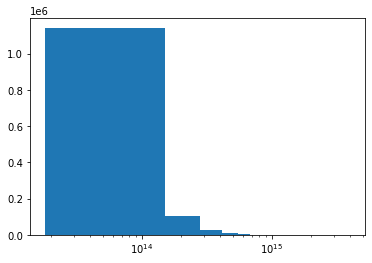

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# plt.hist(np.sqrt(vel[:,0]**2+vel[:,1]**2+vel[:,2]**2))
# plt.hist(vel[:,1], bins=30)
# plt.hist(vel[:,2], bins=30)
plt.hist(mass[:], bins=30)


In [ ]:

for sim_size in sim_size_ini: 
    for bulk_species in bulk_species_ini: 
        for sim in sim_type_ini:
            for snap_num in snap_num_ini: 
                load_data(sim_size, sim, bulk_species, snap_num, sim_path, halo_file, verbose=True);
                ##########
                ##########
                for ngrid in ngrid_ini: 
                    number_smaples = ngrid*ngrid*ngrid;
#                     sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                    sub_box_lists = obj.All_sub_box(ngrid);
                    ## Reseting the dictionary!
                    column_names = ['simulation','parameters','bulk_species','n_grid', 'sub_box_index','bulk_vel_halos_i', 'halos_vel_i']
                    df = pd.DataFrame(columns=column_names)
                    for i in range(number_smaples):
                        sub_box_index = sub_box_lists[i]
#                        ##############################
#                        ##### All halos velocities in each cell
#                        ##############################
                        halos_i = obj.halos_in_cell(ngrid, pos, vel, mass, sub_box_index)# Gives the information of objects in a cell defined by sub-box index!

                        #########################################
                        ### Bulk velocity computation in grid i
                        #########################################
                        bulk_vel_halos_i = obj.velocity_bulk(ngrid, halo_all[:,:3], halo_all[:,3:6], sub_box_index)[:3] # Bulk velocities using halos

                        ##############################
                        ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                        ##############################
#                         vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                         vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

#                         vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                         vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

#                         vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                         vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                    #     data_saved = {
                    #         'simulation':sim,
                    #         'parameters':parameters,
                    #         'bulk_species':bulk_species,
                    #         'n_grid': ngrid,
                    #         'sub_box_index': sub_box_index,
                    #         'bulk_vel_halos_i': bulk_vel_halos_i,
                    #         'bulk_vel_i': bulk_vel_cdm_i,
                    #         'vp1.v_b':vdvb_p1_bulk_cdm ,
                    #         'vp2.v_b':vdvb_p2_bulk_cdm ,
                    #         'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                    #         'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                    #         'v_h.v_b':vdvb_all_bulk_cdm ,
                    #         'v_h.v_b(halos)':vdvb_all_bulk_halos 
                    #         }
                    #     df = df.append(data_saved, ignore_index=True)
                    # if not os.path.exists(save_path):
                    #     os.makedirs(save_path)
                    # with open(save_path+'/data_ngrid_'+str(ngrid)+'_sim_'+sim_size+'_'+sim+'_snap_'+str(snap_num)+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
                    #     pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                    # print("\t \t *** number of grid: "+str(ngrid)+" is finished!")
            print("\033[34m \033[1m  \n \t The main loop is finished \033[0m")
            print("\033[34m \033[1m ************************************************* \033[0m")



In [82]:
# with open('./output/data_ngrid_3_sim_L_2048_Ngrid_4096_0.3ev_snap_4.pickle','rb') as handle:
#     df = pickle.load(handle)
# df[df['sub_box_index'].apply(lambda x: x == [1, 2, 1])].iloc[0]['halo_vel']



